# 03 · Sampling: from noise back to data

Now the payoff. We have $\varepsilon_\theta(x_t, t)$. To generate, start from pure
noise $x_T\sim\mathcal N(0,I)$ and reverse one step at a time. The DDPM reverse
step uses the predicted noise to form the posterior mean, then adds a little fresh
noise (except on the very last step):

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\Big) + \sqrt{\tilde\beta_t}\,z$$

This is `nanodiffusion.samplers.ddpm_sample`. Let's watch noise turn into a spiral.

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import pick_device, set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule
from nanodiffusion.models import MLPDenoiser
from nanodiffusion.objectives import ddpm_eps_loss
from nanodiffusion.samplers import ddpm_sample

set_seed(0)
device = pick_device()
schedule = NoiseSchedule.make("cosine", 200).to(device)
data = toy2d("swiss_roll", 8000).to(device)

## Load the model from notebook 02 (or train a quick one)

So this notebook runs standalone, we train briefly if no checkpoint exists.

In [2]:
import os
model = MLPDenoiser().to(device)
ckpt = "../checkpoints/toy_mlp.pt"
if os.path.exists(ckpt):
    model.load_state_dict(torch.load(ckpt, map_location=device))
    print("loaded", ckpt)
else:
    print("no checkpoint — training a quick model...")
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    for step in range(2000):
        idx = torch.randint(0, data.shape[0], (512,), device=device)
        loss = ddpm_eps_loss(model, data[idx], schedule)
        opt.zero_grad(); loss.backward(); opt.step()
    print(f"trained, final loss {loss.item():.4f}")

loaded ../checkpoints/toy_mlp.pt


## Generate samples

Draw fresh noise and reverse it all the way to $x_0$. Compare the generated cloud
to the real data — they should look like the same distribution.

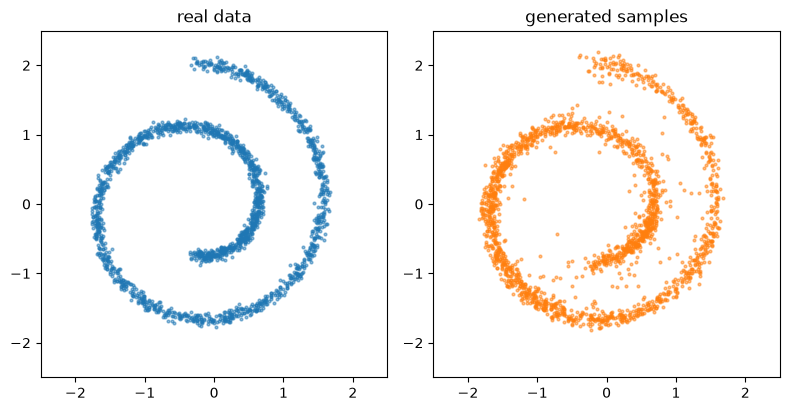

In [3]:
gen = ddpm_sample(model, schedule, shape=(2000, 2), device=device)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
scatter_2d(a1, data[:2000], "real data")
scatter_2d(a2, gen, "generated samples", color="C1")
plt.tight_layout(); plt.show()

## Watch the reverse trajectory

The sampler can hand back every intermediate $x_t$. Plotting a few shows the
noise blob (left) reorganizing into the swiss roll (right) — the forward process
from notebook 00, run in reverse.

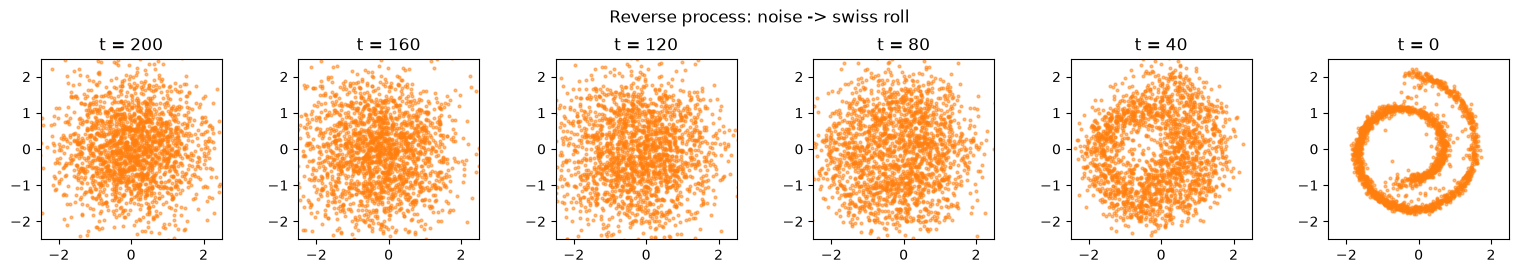

In [4]:
_, traj = ddpm_sample(model, schedule, (2000, 2), device=device, return_trajectory=True)
# traj[0] = x_T (noise) ... traj[-1] = x_0 (data)
picks = [0, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(1, len(picks), figsize=(2.6 * len(picks), 2.6))
for ax, i in zip(axes, picks):
    step = schedule.timesteps - i  # label with the diffusion timestep
    scatter_2d(ax, traj[i], f"t = {max(step,0)}", color="C1")
plt.suptitle("Reverse process: noise -> swiss roll")
plt.tight_layout(); plt.show()

## 🎉 You built a diffusion model

From scratch: forward noising, an ε-prediction network, an MSE loss, and an
ancestral sampler — and it generates new samples from noise.

Everything here is in the `nanodiffusion` package now. In **Part 2** we swap the
MLP for a **U-Net** and point this same pipeline at MNIST for our first real
images, then DDIM for fast sampling and guidance for conditional generation.